In [2]:
import sys
import os

os.chdir('../')
os.getcwd()

'c:\\Users\\luisa\\Documents\\LX1_GitHub_Repos\\ai_cheme_examples'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from scipy import stats
from scipy import interpolate
from scipy.interpolate import CubicSpline

In [4]:
data = pd.read_excel('data/3.0-lbm-WWT.xlsx')

data['Date'] = data['Date'] - data['Date'][0]

data.iloc[:, 1:]=(data.iloc[:, 1:] - data.iloc[:, 1:].mean())/data.iloc[:, 1:].std()

data.head()

,Date,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
0,0,-0.779349,NaN,1.505893,-1.077060,-0.293677,-0.227113,-1.149290,NaN,-1.696720,3.469443
1,1,-0.949799,NaN,-1.790925,-1.369496,0.486085,-1.491272,-1.359132,NaN,0.409719,3.469443
2,2,-0.550054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.277555
3,3,-0.529762,NaN,0.406954,-0.544922,-0.577226,-0.322521,-0.732787,NaN,-0.881069,-0.277555
4,4,0.480762,NaN,-0.729880,-0.496982,-0.739255,0.035260,0.163809,NaN,0.073164,-0.277555


In [5]:
def plot_data(data):

    fig = plt.figure(figsize=(10, 4))
    axs0 = fig.add_subplot(1, 1, 1)

    for col in data.iloc[:, 1:].columns:

        axs0.plot(np.asarray(data.iloc[:, 0]), np.asarray(data[col]), label = col)


    axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
    axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

    axs0.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large', 
                        #rotation=45
                        )

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs0.spines[ax].set_linewidth(1)

    axs0.set_ylim(-2, 4.5)

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.legend(frameon = False, ncol = 4)
    plt.tight_layout()

    plt.show()

    return None

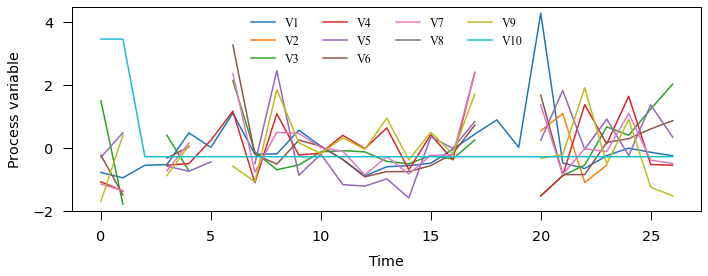

In [6]:
plot_data(data)

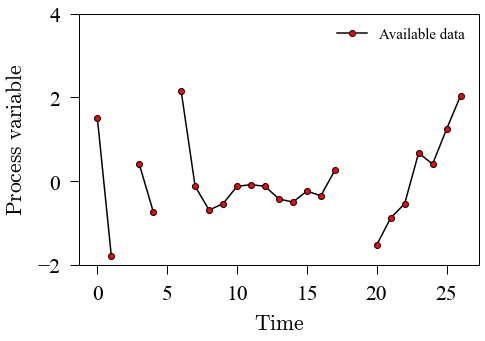

In [24]:
X = np.asarray(data.iloc[:, 0])
y = np.asarray(data.iloc[:, 3])


# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=13)


# plt.scatter(X_train, y_train)
# plt.scatter(X_test, y_test)

fig = plt.figure(figsize=(7, 5))
axs0 = fig.add_subplot(1, 1, 1)

axs0.plot(X, y, color = 'k', marker = 'o', markeredgecolor = 'k', markerfacecolor = 'r', ls = '-', label = 'Available data')


axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

axs0.tick_params(direction='out',
                    pad=10,
                    length=9,
                    width=1,
                    labelsize='x-large')

axs0.tick_params(which='minor',
                    direction='out',
                    pad=10,
                    length=5,
                    width=1,
                    labelsize='x-large')

for ax in ['top', 'bottom', 'left', 'right']:
    axs0.spines[ax].set_linewidth(1)

axs0.set_ylim(-2, 4)

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

plt.legend(frameon = False)
plt.tight_layout()

plt.savefig('figures/example-2-2b.png', dpi = 300)

plt.show()


In [8]:
train_set = np.array([X, y]).reshape(2, -1).transpose()

train_set = np.delete(train_set, [2, 5, 18, 19], 0)

X_train = train_set[:, 0]
y_train = train_set[:, 1]

X_test = np.array([2, 5, 18, 19])
y_test = np.array([-0.2, 1.0, -0.1, 0.1])

train_set = train_set[train_set[:, 0].argsort()]

X_train_sorted = train_set[:, 0]
y_train_sorted = train_set[:, 1]

train_set

array([[ 0.        ,  1.50589314],
       [ 1.        , -1.79092543],
       [ 3.        ,  0.40695362],
       [ 4.        , -0.72988037],
       [ 6.        ,  2.15009907],
       [ 7.        , -0.12356891],
       [ 8.        , -0.69198591],
       [ 9.        , -0.54040804],
       [10.        , -0.12356891],
       [11.        , -0.08567445],
       [12.        , -0.12356891],
       [13.        , -0.42672464],
       [14.        , -0.50251358],
       [15.        , -0.23725231],
       [16.        , -0.35093571],
       [17.        ,  0.25537575],
       [20.        , -1.52566417],
       [21.        , -0.88145824],
       [22.        , -0.54040804],
       [23.        ,  0.67221488],
       [24.        ,  0.40695362],
       [25.        ,  1.24063188],
       [26.        ,  2.03641567]])

In [9]:
f0 = interpolate.interp1d(X_train_sorted, y_train_sorted)
f1 = CubicSpline(X_train_sorted, y_train_sorted)

In [10]:
y_predicted0 = f0(X_test).reshape(-1, )
y_predicted1 = f1(X_test).reshape(-1, )

y_predicted0train = f0(X_train).reshape(-1, )
y_predicted1train = f1(X_train).reshape(-1, )

y_predicted = []

for y in [y_predicted0train, y_predicted1train]:
    predicted_set = np.array([X_train.reshape(-1, ), y]).reshape(2, -1).transpose()
    predicted_set = predicted_set[predicted_set[:, 0].argsort()]
    X_train_sorted = predicted_set[:, 0]
    y = predicted_set[:, 1]

    y_predicted.append(y)

for y in [y_predicted0, y_predicted1]:
    predicted_set = np.array([X_test.reshape(-1, ), y]).reshape(2, -1).transpose()
    predicted_set = predicted_set[predicted_set[:, 0].argsort()]
    X_test_sorted = predicted_set[:, 0]
    y = predicted_set[:, 1]

    y_predicted.append(y)



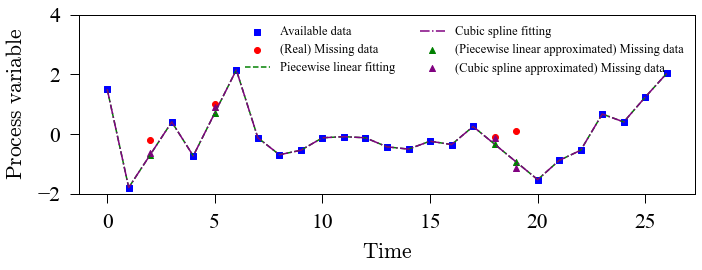

In [11]:
fig = plt.figure(figsize=(10, 4))
axs0 = fig.add_subplot(1, 1, 1)

axs0.scatter(X_train, y_train, color = 'b', label = 'Available data', marker = 's')
axs0.scatter(X_test, y_test, color = 'r', label = '(Real) Missing data')

axs0.plot(X_train_sorted, y_predicted[0], color = 'g', ls = '--', label = 'Piecewise linear fitting')
axs0.plot(X_train_sorted, y_predicted[1], color = 'purple', ls = '-.', label = 'Cubic spline fitting')


axs0.scatter(X_test_sorted, y_predicted[2], color = 'g', marker = '^', label = '(Piecewise linear approximated) Missing data')
axs0.scatter(X_test_sorted, y_predicted[3], color = 'purple', marker = '^', label = '(Cubic spline approximated) Missing data')

axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

axs0.tick_params(direction='out',
                    pad=10,
                    length=9,
                    width=1,
                    labelsize='x-large')

axs0.tick_params(which='minor',
                    direction='out',
                    pad=10,
                    length=5,
                    width=1,
                    labelsize='x-large')

for ax in ['top', 'bottom', 'left', 'right']:
    axs0.spines[ax].set_linewidth(1)

axs0.set_ylim(-2, 4)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

plt.legend(frameon = False, ncol=2, fontsize = 'small')
plt.tight_layout()

plt.savefig('figures/example-2-2.png', dpi = 300)

plt.show()